Imports

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
np.random.seed(42)
random.seed(42)

In [2]:
DATA_PATH='Data/mnist.npz'

Load data using numpy

In [3]:
data = np.load(DATA_PATH)
print(data.files)

['x_test', 'x_train', 'y_train', 'y_test']


In [4]:
X_train = data['x_train']
y_train = data['y_train']

X_test = data['x_test']
y_test = data['y_test']

In [5]:
print(X_train.shape, y_train.shape)  
print(X_test.shape, y_test.shape)   

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


Flatten and Normalize

In [6]:
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

In [7]:
print(X_train.shape, y_train.shape)  
print(X_test.shape, y_test.shape)   

(60000, 784) (60000,)
(10000, 784) (10000,)


Select data corresponding to classes 4 and 9 and label as -1 and 1

In [8]:
classes = [4, 9]

y_train_idx = [i for i in range(y_train.shape[0]) if y_train[i] in classes]
y_test_idx = [i for i in range(y_test.shape[0]) if y_test[i] in classes]

X_train = X_train[y_train_idx, :]
X_test = X_test[y_test_idx, :]
y_train = np.where(y_train[y_train_idx] == 4, -1, 1)
y_test  = np.where(y_test[y_test_idx] == 4, -1, 1)

Split train into train and validation set (shuffled)

In [9]:
idx_neg = np.where(y_train == -1)[0]  
idx_pos = np.where(y_train == 1)[0]    

np.random.shuffle(idx_neg)
np.random.shuffle(idx_pos)

val_neg = idx_neg[:1000]
val_pos = idx_pos[:1000]

val_idx = np.concatenate([val_neg, val_pos])
train_idx = np.setdiff1d(np.arange(len(y_train)), val_idx)

X_val = X_train[val_idx]
y_val = y_train[val_idx]

X_train = X_train[train_idx]
y_train = y_train[train_idx]

In [10]:
print("X_train.shape:", X_train.shape)
print("y_train.shape:", y_train.shape)
print("X_val.shape:", X_val.shape)
print("y_val.shape:", y_val.shape)
print("X_test.shape:", X_test.shape)
print("y_test.shape:", y_test.shape)

X_train.shape: (9791, 784)
y_train.shape: (9791,)
X_val.shape: (2000, 784)
y_val.shape: (2000,)
X_test.shape: (1991, 784)
y_test.shape: (1991,)


In [11]:
d = X_train.shape[1]
N_train = X_train.shape[0]
N_val = X_val.shape[0]
N_test = X_test.shape[0]

PCA

In [12]:
def pca_fit(X,p):
    
    mu = np.mean(X, axis=0, keepdims=True)
    X_centered = X - mu

    cov_matrix = 1/X.shape[0] * X_centered.T @ X_centered

    # Eigenvalue problem on covariance matrix
    eigvalues, eigvectors = np.linalg.eigh(cov_matrix)

    # sort eigenvectors in descending order of eigenvalues
    eig_idx = np.argsort(eigvalues)[::-1]      
    eigvalues = eigvalues[eig_idx]
    eigvectors = eigvectors[:, eig_idx] 

    eigenvectors_p = eigvectors[:, :p]

    return eigenvectors_p, mu
    
def pca_transform(X, eigenvectors_p, mu):
    return (X - mu) @ eigenvectors_p

In [13]:
# Reduce dim to 5 using PCA
pca_dim=5
W, mu = pca_fit(X_train, pca_dim)
X_train_5 = pca_transform(X_train, W, mu)
X_val_5 = pca_transform(X_val, W, mu)
X_test_5 = pca_transform(X_test, W, mu)

Initializing weight of each train sample

In [14]:
# w=1/N
w = np.ones(N_train) / N_train

Helper function: Stump prediction

In [15]:
# X = nxd input for stump
# feature = PCA dimension index used for split 
# threshold = value for partitioning
# mean_left = value predicted for samples where feature<=threshold 
# mean_right = value predicted for samples where feature>threshold 
# Returns (n,) continuous predictions 
def stump_predict_reg(X, feature, threshold, mean_left, mean_right):
    pred = np.zeros(X.shape[0])
    pred[X[:, feature] <= threshold] = mean_left
    pred[X[:, feature] > threshold] = mean_right
    return pred

Helper function: Calculate SSR

In [16]:
# Function to calculate SSR for a potential split
def calculate_ssr(y_left, y_right):
    # Calculate means for each partition 
    mean_left = np.mean(y_left) if len(y_left) > 0 else 0
    mean_right = np.mean(y_right) if len(y_right) > 0 else 0
    # Calculate SSR from mean 
    ssr_left = np.sum((y_left - mean_left)**2)
    ssr_right = np.sum((y_right - mean_right)**2)
    return ssr_left + ssr_right, mean_left, mean_right

Helper function: Train one stump

In [17]:
# Finds the best split by minimizing SSR
def train_stump_reg(X, y):
    n, d = X.shape
    best_feature, best_threshold = None, None
    best_m_left, best_m_right = None, None
    min_ssr = float('inf')
    # iterate through all dimensions
    for feature in range(d):
        values = np.sort(np.unique(X[:, feature]))
        thresholds = (values[:-1] + values[1:]) / 2
        # sampling only 1000 random thresholds (midpoints)
        if len(thresholds) > 1000:
            idx = np.random.choice(len(thresholds), 1000, replace=False)
            thresholds = thresholds[idx]
        for thresh in thresholds:
            # partition the data 
            left_mask = X[:, feature] <= thresh
            right_mask = ~left_mask
            y_left = y[left_mask]
            y_right = y[right_mask]
            # skip if a partition is empty
            if len(y_left) == 0 or len(y_right) == 0:
                continue
            # SSR for this split 
            current_ssr, m_left, m_right = calculate_ssr(y_left, y_right)
            # select split with minimum SSR 
            if current_ssr < min_ssr:
                min_ssr = current_ssr
                best_feature = feature
                best_threshold = thresh
                best_m_left = m_left
                best_m_right = m_right
    return best_feature, best_threshold, best_m_left, best_m_right, min_ssr

GradientBoost: Loop (η=0.01)

In [18]:
def run_gradient_boosting(X_train_5, y_train, X_val_5, y_val, eta, num_stumps=300):
    models = []
    val_mses = []
    train_mses = [] 

    # Current targets initialized to original labels 
    current_y_train = y_train.astype(float).copy()

    # Cumulative predictions for validation set
    cum_val_pred = np.zeros(len(y_val))
    # Cumulative predictions for training set to track error
    cum_train_pred = np.zeros(len(y_train))

    pbar = tqdm(range(num_stumps), desc=f"η = {eta}")
    for t in pbar:
        # Fit stump on current residuals 
        f, th, ml, mr, ssr = train_stump_reg(X_train_5, np.sign(current_y_train))
        # Get predictions on train set for updating residuals
        train_stump_pred = stump_predict_reg(X_train_5, f, th, ml, mr)
        # Update current residuals: y = y - eta * h(x) 
        current_y_train -= eta * train_stump_pred 
        # Update cumulative training predictions and record MSE
        cum_train_pred += eta * train_stump_pred
        train_mses.append(np.mean((y_train - cum_train_pred)**2))
        # Store model
        models.append((f, th, ml, mr, ssr))
        # Evaluate on Validation set
        val_stump_pred = stump_predict_reg(X_val_5, f, th, ml, mr)
        cum_val_pred += eta * val_stump_pred 
        mse = np.mean((y_val - cum_val_pred)**2) 
        val_mses.append(mse)
        pbar.set_postfix({
            "tr_mse": f"{train_mses[-1]:.4f}", 
            "val_mse": f"{mse:.4f}", 
            "ssr": f"{ssr:.2f}"
        })
    
    return models, train_mses, val_mses

In [19]:
# Parameters for training
eta = 0.01
num_stumps = 300

models, train_mses, val_mses = run_gradient_boosting(X_train_5, y_train, X_val_5, y_val, eta, num_stumps)

η = 0.01: 100%|██████████| 300/300 [02:19<00:00,  2.15it/s, tr_mse=1.1664, val_mse=1.1855, ssr=7981.09]


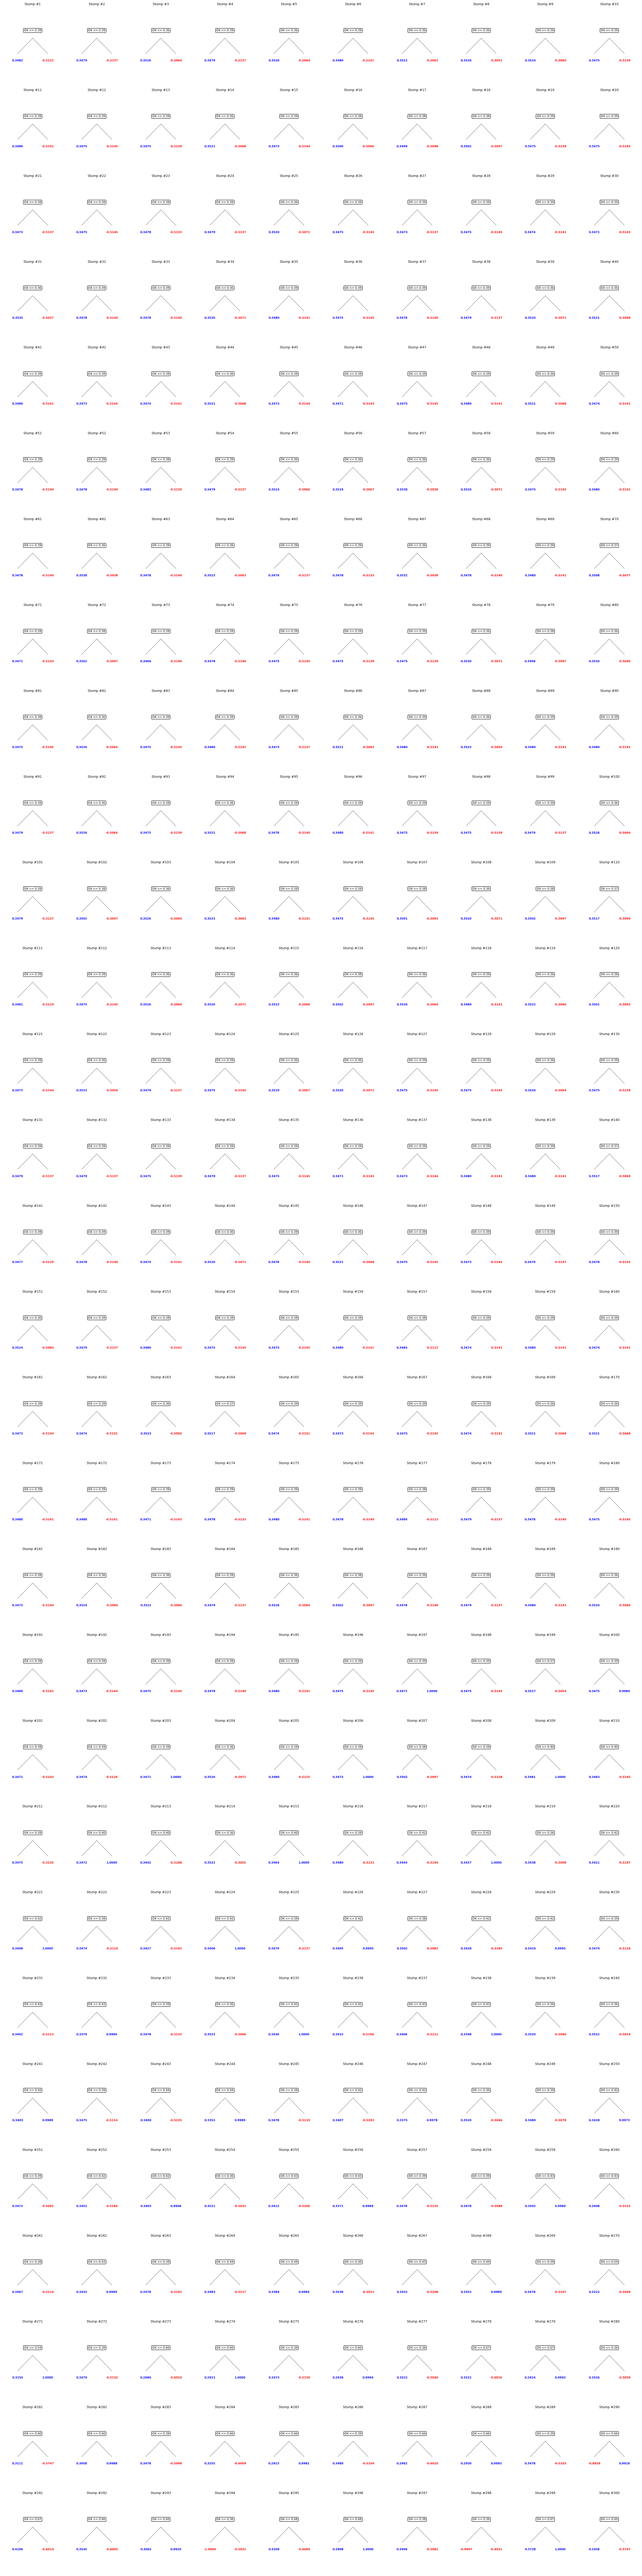

In [20]:
n_to_show = 300 
cols = 10
rows = 30

fig, axes = plt.subplots(rows, cols, figsize=(25, 100))
axes = axes.flatten()

for i in range(n_to_show):
    f, th, ml, mr,_ = models[i] 
    
    axes[i].set_title(f"Stump #{i+1}", fontsize=9)
    
    axes[i].text(0.5, 0.7, f"D{f} <= {th:.2f}", 
                 ha='center', va='center', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#f9f9f9', edgecolor='black'))
    
    axes[i].text(0.25, 0.3, f"{ml:.4f}", ha='center', fontsize=8, 
                 color='blue' if ml >= 0 else 'red', fontweight='bold')
    axes[i].text(0.75, 0.3, f"{mr:.4f}", ha='center', fontsize=8, 
                 color='blue' if mr >= 0 else 'red', fontweight='bold')
    
    axes[i].plot([0.5, 0.25], [0.6, 0.4], color='black', lw=0.5)
    axes[i].plot([0.5, 0.75], [0.6, 0.4], color='black', lw=0.5)

    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_axis_off()

plt.tight_layout() 
plt.show()

MSE Plot

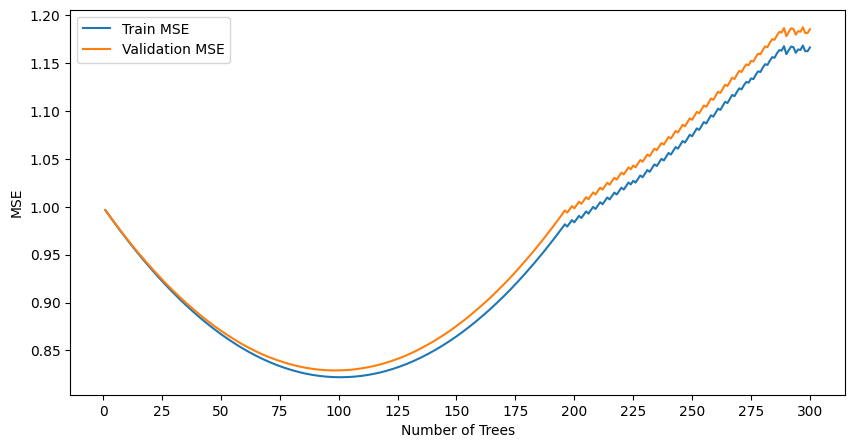

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(range(1, 301), train_mses, label="Train MSE")
plt.plot(range(1, num_stumps + 1), val_mses, label="Validation MSE")

plt.xlabel("Number of Trees")
plt.ylabel("MSE")
plt.xticks(range(0, 301, 25))
plt.legend()

plt.show()

Determining best model and test accuracy

In [24]:
# Taking first index of max val acc
best_t_reg = np.argmin(val_mses) + 1

In [25]:
print(f"Best Iteration: {best_t_reg}")

Best Iteration: 98


In [26]:
# Print info of best stump

best_idx_reg = best_t_reg - 1

best_f, best_th, best_ml, best_mr, best_ssr = models[best_idx_reg]
best_val_mse = val_mses[best_idx_reg]
best_train_mse = train_mses[best_idx_reg] 

print(f"Best Iteration: {best_t_reg}")
print(f"Validation MSE: {best_val_mse:.4f}")
print(f"Cumulative Train MSE: {best_train_mse:.4f}")
print(f"Individual Stump SSR: {best_ssr:.4f}")
print(f"Stump Feature Index: {best_f}")
print(f"Stump Threshold: {best_th:.4f}")
print(f"Mean Left: {best_ml:.4f}")
print(f"Mean Right: {best_mr:.4f}")

Best Iteration: 98
Validation MSE: 0.8291
Cumulative Train MSE: 0.8221
Individual Stump SSR: 8060.3418
Stump Feature Index: 4
Stump Threshold: 0.3903
Mean Left: 0.3475
Mean Right: -0.5139


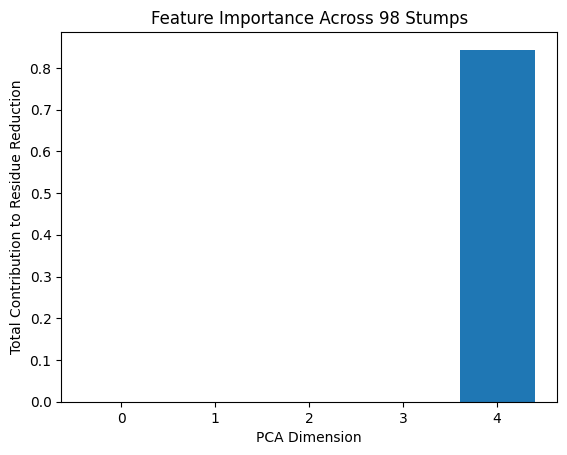

In [27]:
feature_importance = np.zeros(pca_dim) 

for i in range(best_t_reg):
    f, th, ml, mr,_ = models[i] 

    contribution = eta * abs(ml - mr)
    feature_importance[f] += contribution

plt.bar(range(pca_dim), feature_importance)
plt.xlabel("PCA Dimension")
plt.ylabel("Total Contribution to Residue Reduction")
plt.title(f"Feature Importance Across {best_t_reg} Stumps")
plt.show()

In [28]:
cum_test_pred = np.zeros(len(y_test))
for i in range(best_t_reg):
    f, th, ml, mr,_ = models[i]
    cum_test_pred += eta * stump_predict_reg(X_test_5, f, th, ml, mr)

test_mse = np.mean((y_test - cum_test_pred)**2)
print(f"Test MSE: {test_mse:.4f}")

Test MSE: 0.8355


Training Loop for different η values

In [29]:
learning_rates = [0.001, 0.01, 0.1, 0.2, 0.5, 1.0] 
results_dict = {}

for lr in learning_rates:
    
    models, train_mses, val_mses = run_gradient_boosting(X_train_5, y_train, X_val_5, y_val, lr, num_stumps)
    
    best_t_reg = np.argmin(val_mses) + 1
    best_idx_reg = best_t_reg - 1
    
    # Calculate test MSE using the first best_t_reg trees
    cum_test_pred = np.zeros(len(y_test))
    for i in range(best_t_reg):
        f, th, ml, mr, _ = models[i]
        # Use lr 
        cum_test_pred += lr * stump_predict_reg(X_test_5, f, th, ml, mr)
    
    test_mse = np.mean((y_test - cum_test_pred)**2)
    
    # Store for analysis
    results_dict[lr] = {
        "models": models,
        "train_mses": train_mses,
        "val_mses": val_mses,
        "test_mse": test_mse,
        "best_t": best_t_reg,
        "best_val_mse": val_mses[best_idx_reg]
    }

η = 1.0: 100%|██████████| 300/300 [02:29<00:00,  2.01it/s, tr_mse=0.9525, val_mse=1.0065, ssr=7668.42]


Plots

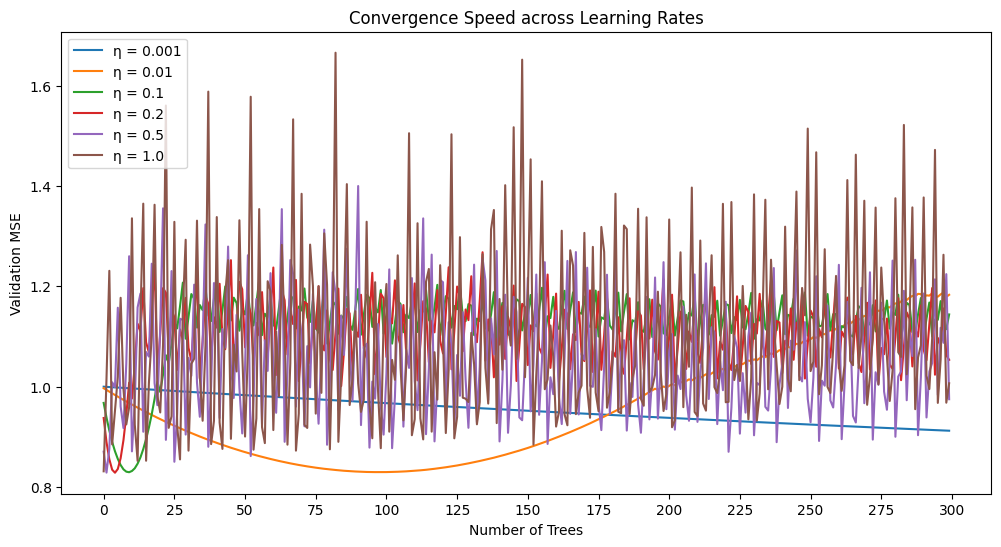

In [30]:
plt.figure(figsize=(12, 6))
for lr, data in results_dict.items():
    plt.plot(data['val_mses'], label=f'η = {lr}')
plt.xlabel("Number of Trees")
plt.xticks([i for i in range(0,301,25)])
plt.ylabel("Validation MSE")
plt.title("Convergence Speed across Learning Rates")
plt.legend()
plt.show()

In [31]:
summary_data = []
for lr, data in results_dict.items():
    summary_data.append({
        "Learning Rate (η)": lr,
        "Optimal Trees (Best T)": data['best_t'],
        "Min Val MSE": round(data['best_val_mse'], 5),
        "Final Test MSE": round(data['test_mse'], 5)
    })
df_summary = pd.DataFrame(summary_data)
print(df_summary.sort_values(by="Final Test MSE"))

   Learning Rate (η)  Optimal Trees (Best T)  Min Val MSE  Final Test MSE
4              0.500                       2      0.82819         0.83432
2              0.100                      10      0.82897         0.83496
1              0.010                      99      0.82914         0.83539
3              0.200                       5      0.82797         0.83540
5              1.000                       1      0.83080         0.83680
0              0.001                     300      0.91182         0.91413
